In [1]:
import matplotlib.pyplot as plt
import numpy as np
from scipy import ndimage as ndi
import skimage as ski
from PIL import Image
import cv2

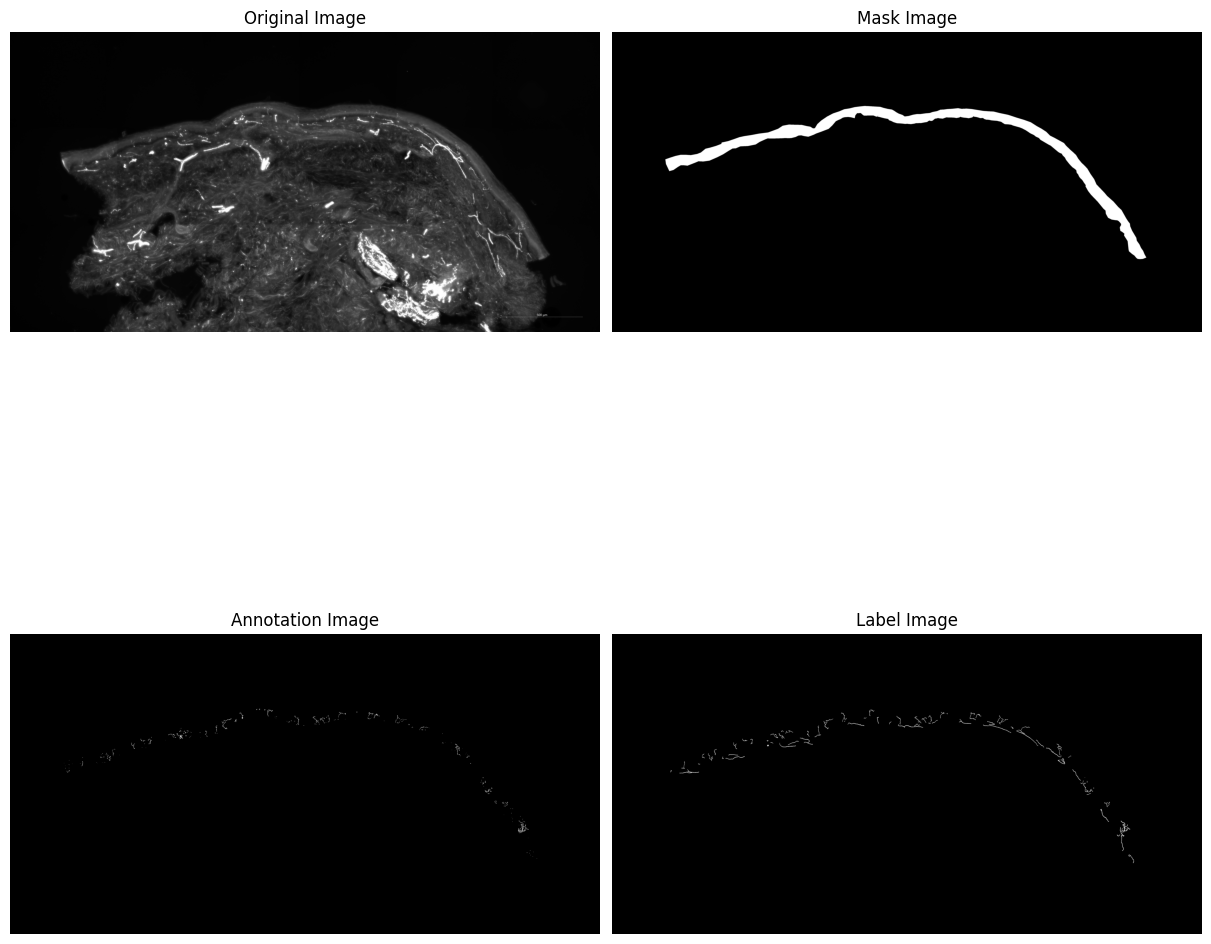

In [2]:
IMAGE_ID = 'S1585-2_a'

base_path = f"../data/{IMAGE_ID}/"

orig_img = cv2.imread(f"{base_path}/image.png")[:, :, 1]
mask_img = cv2.imread(f"{base_path}/mask.png", cv2.IMREAD_GRAYSCALE)
annotation_img = cv2.imread(f"{base_path}/annotation.png", cv2.IMREAD_GRAYSCALE)
label_img = cv2.imread(f"{base_path}/label.png", cv2.IMREAD_GRAYSCALE)



_, axes = plt.subplots(nrows=2, ncols=2, figsize=(12, 12), constrained_layout=True)
axes[0, 0].imshow(orig_img, cmap='gray')
axes[0, 0].set_title('Original Image')
axes[0, 0].set_axis_off()
axes[0, 1].imshow(mask_img, cmap='gray')
axes[0, 1].set_title('Mask Image')
axes[0, 1].set_axis_off()
axes[1, 0].imshow(annotation_img, cmap='gray')
axes[1, 0].set_title('Annotation Image')
axes[1, 0].set_axis_off()
axes[1, 1].imshow(label_img, cmap='gray')
axes[1, 1].set_title('Label Image')
axes[1, 1].set_axis_off()
plt.show()

In [ ]:
from neural_reconstruction.ui.main_pipeline import NeuralReconstructionPipeline
from neural_reconstruction.core.preprocessing.pipeline import   PipelineConfig as PreprocessingPipelineConfig



preprocess_config = PreprocessingPipelineConfig.from_dict(
            {
                "morphology": {"closing_kernel": 0, "opening_kernel": 3},
                "mask": {"dilate_offset": 50},
                "background": {
                    "method": "morphology",
                    # "method": "rolling_ball",
                    "radius": 25,
                },
                "threshold": {"use_full_roi": False},
                "normalization": {"enabled": False},
            }
        )


reconstruct_config ={
            "connectivity": 4,
            "min_area": 0,
            "segment_length": 5.0,
            "min_edge_length": None,
            "prune_threshold": 0.0,
            "spacing": 1.0,
            "search_radius": 20.0,
            "max_cost_threshold": 0.98,
            "intensity_weight": 1,
            "shape_weight": 0.0,
        }

pipeline = NeuralReconstructionPipeline(preprocessing_config=preprocess_config, reconstruction_config=reconstruct_config)



pipeline_res = pipeline.run(annotation_img,mask_img,orig_img)



print(f"Nodes: {pipeline_res.mst_forest.number_of_nodes()}, Edges: {pipeline_res.mst_forest.number_of_edges()}")

695
Nodes: 2002, Edges: 1825


In [4]:
from matplotlib.colors import Normalize

graph = pipeline_res.mst_forest
def viz_cost_map(graph):
	viz_image = cv2.cvtColor(orig_img.copy(), cv2.COLOR_GRAY2BGR)
	weights = []
	for u, v, data in graph.edges(data=True):
		weight = data.get("weight", None)
		if weight is not None:
			weights.append(weight)


	min_weight = min(weights)
	max_weight = max(weights)

	print(f"Edge weights - Min: {min_weight:.2f}, Max: {max_weight:.2f}, Mean: {np.mean(weights):.2f}")

	# Get colormap
	cmap = plt.get_cmap('viridis')

	normalizer = Normalize(vmin=min_weight, vmax=max_weight)
	# Create inverted mapper
	norm_func = lambda x: 1.0 - normalizer(x)

	# Draw edges with color mapping
	for u, v, data in graph.edges(data=True):
		weight = data.get("weight", None)

		if weight is None:
			color_bgr = (255, 255, 0)
		else:
			# Map weight to color
			normalized_value = norm_func(weight)
			color_rgba = cmap(normalized_value)  # Returns (r, g, b, a) in [0, 1]

			# Convert to BGR uint8 for OpenCV
			color_bgr = (
				int(color_rgba[2] * 255),  # B
				int(color_rgba[1] * 255),  # G
				int(color_rgba[0] * 255),  # R
			)

			y1, x1 = u
			y2, x2 = v

			path_points = data["path"]
			# Draw path segments
			for i in range(len(path_points) - 1):
				py1, px1 = path_points[i]
				py2, px2 = path_points[i + 1]
				p1 = (int(px1), int(py1))
				p2 = (int(px2), int(py2))
				cv2.line(viz_image, p1, p2, color=color_bgr, thickness=1)


	cv2.imwrite(f"./reconstruction_viz.png", viz_image)

viz_cost_map(graph)

Edge weights - Min: 0.00, Max: 19.94, Mean: 4.06


In [5]:
#  filter out edges with weight > 1 sigma
weights = []
for u, v, data in graph.edges(data=True):
	weight = data.get("weight", None)
	if weight is not None:
		weights.append(weight)
mean_weight = np.mean(weights)
std_weight = np.std(weights)
threshold = mean_weight + 2 * std_weight

print(f"Mean: {mean_weight:.2f}, Std: {std_weight:.2f}, Threshold (mean + 0.5σ): {threshold:.2f}")

# Filter edges and create new graph
filtered_graph = graph.copy()
edges_to_remove = []

for u, v, data in filtered_graph.edges(data=True):
    weight = data.get("weight", None)
    if weight is not None and weight > threshold:
        edges_to_remove.append((u, v))

filtered_graph.remove_edges_from(edges_to_remove)
viz_cost_map(filtered_graph)
print(f"Original edges: {graph.number_of_edges()}, Filtered edges: {filtered_graph.number_of_edges()}")
print(f"Removed {len(edges_to_remove)} edges")

Mean: 4.06, Std: 4.06, Threshold (mean + 0.5σ): 12.18
Edge weights - Min: 0.00, Max: 12.14, Mean: 3.60
Original edges: 1825, Filtered edges: 1753
Removed 72 edges


In [14]:
from neural_reconstruction.core.crosses_detection import SegmentDetector

segmented_graph = SegmentDetector.detect_segments(filtered_graph)

def viz_segments_graph(graph, base_image=None, output_path="./segments_viz.png"):
	"""
	視覺化 graph 中的 segments，每個 segment_id 使用不同顏色

	Args:
		graph: NetworkX graph with segment_id in edge data
		base_image: Base image to overlay (default: orig_img)
		output_path: Output file path
	"""
	if base_image is None:
		base_image = orig_img

	# Create BGR visualization image
	viz_image = cv2.cvtColor(base_image.copy(), cv2.COLOR_GRAY2BGR)

	# Collect all segment IDs
	segment_ids = set()
	for u, v, data in graph.edges(data=True):
		seg_id = data.get("segment_id", None)
		if seg_id is not None:
			segment_ids.add(seg_id)

	if not segment_ids:
		print("Warning: No segment_id found in graph edges")
		cv2.imwrite(output_path, viz_image)
		return

	# Generate distinct colors for each segment
	num_segments = len(segment_ids)
	print(f"Total segments: {num_segments}")

	# Use better color distribution with full HSV range and varying saturation/value
	segment_colors = {}
	for i, seg_id in enumerate(sorted(segment_ids)):
		# Use full 0-179 hue range in OpenCV
		hue = int((i * 179) / max(num_segments, 1))
		# Alternate saturation and value for better distinction
		saturation = 255 if i % 2 == 0 else 200
		value = 255 if (i // 2) % 2 == 0 else 220
		
		hsv_color = np.uint8([[[hue, saturation, value]]])
		bgr_color = cv2.cvtColor(hsv_color, cv2.COLOR_HSV2BGR)[0][0]
		segment_colors[seg_id] = tuple(map(int, bgr_color))

	# Draw each edge with its segment color
	for u, v, data in graph.edges(data=True):
		seg_id = data.get("segment_id", None)
		path_points = data.get("path", None)

		if seg_id is None or path_points is None:
			continue

		color_bgr = segment_colors[seg_id]

		# Draw path segments
		for i in range(len(path_points) - 1):
			py1, px1 = path_points[i]
			py2, px2 = path_points[i + 1]
			p1 = (int(px1), int(py1))
			p2 = (int(px2), int(py2))
			cv2.line(viz_image, p1, p2, color=color_bgr, thickness=1)

	cv2.imwrite(output_path, viz_image)
	print(f"Visualization saved to {output_path}")

	return viz_image

# Test the visualization
viz_segments_graph(segmented_graph)

Total segments: 890
Visualization saved to ./segments_viz.png


array([[[6, 6, 6],
        [6, 6, 6],
        [6, 6, 6],
        ...,
        [7, 7, 7],
        [7, 7, 7],
        [7, 7, 7]],

       [[6, 6, 6],
        [6, 6, 6],
        [5, 5, 5],
        ...,
        [7, 7, 7],
        [7, 7, 7],
        [7, 7, 7]],

       [[6, 6, 6],
        [6, 6, 6],
        [6, 6, 6],
        ...,
        [7, 7, 7],
        [7, 7, 7],
        [7, 7, 7]],

       ...,

       [[6, 6, 6],
        [6, 6, 6],
        [6, 6, 6],
        ...,
        [7, 7, 7],
        [7, 7, 7],
        [7, 7, 7]],

       [[6, 6, 6],
        [6, 6, 6],
        [6, 6, 6],
        ...,
        [7, 7, 7],
        [7, 7, 7],
        [7, 7, 7]],

       [[6, 6, 6],
        [6, 6, 6],
        [6, 6, 6],
        ...,
        [7, 7, 7],
        [7, 7, 7],
        [7, 7, 7]]], shape=(2867, 5632, 3), dtype=uint8)